# Week 6 — AI Ethics, Bias Analysis, and Fairness Assessment

**Goal.** Perform an in-depth ethical audit of the Week 3 tuned Random
Forest churn model: identify potential biases, quantify fairness across
protected/sensitive attributes using standard fairness metrics, and
propose concrete, practical mitigation strategies.

**A note on tooling.** This notebook environment has no internet access, so
the `fairlearn` and `aif360` packages (the standard libraries for this kind
of audit) cannot be installed. Every fairness metric used below is instead
implemented directly from its standard definition in the fairness
literature, using only numpy/pandas/scikit-learn — each is simple enough
(a selection rate, a true/false positive rate, a ratio) that this is a
faithful, correct implementation of the metric, not an approximation.

**Structure of this notebook:**
1. Recap: rebuild the Week 3 tuned Random Forest model
2. Audit setup: sensitive attributes and group definitions
3. Disparate impact analysis
4. Demographic parity
5. Equalized odds and equal opportunity
6. Predictive parity and calibration by group
7. Proxy-variable analysis (indirect bias via correlated features)
8. Intersectional analysis
9. Summary of findings and mitigation strategies (code demonstration)

**How to run this notebook.** Requirements: `python>=3.9`, `numpy`,
`pandas`, `matplotlib`, `seaborn`, `scikit-learn`. `RANDOM_STATE = 42` is
fixed and reused everywhere, so re-running reproduces identical numbers and
plots. No internet access or external files are required.

In [1]:
# --- Imports & global configuration -----------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Environment ready. Random seed fixed at", RANDOM_STATE)

Environment ready. Random seed fixed at 42


## 1. Model Recap

This reproduces the exact leak-free preprocessing pipeline and tuned
Random Forest from Weeks 2-3 (condensed here). Two sensitive attributes are
retained alongside the model-ready features specifically for this audit —
`gender` and an `age_group` derived from `age` — even though the model
itself does not use `gender` directly as a raw predictive feature in a
one-hot-encoded form (see Section 2 for why this doesn't automatically
mean the model is unbiased with respect to gender).

In [2]:
# --- Simulate the same messy customer-churn dataset as Weeks 2-5 ------------
N = 2000
rng = np.random.default_rng(RANDOM_STATE)

tenure_months = rng.gamma(shape=2.0, scale=12, size=N).clip(0, 72).round(0)
contract_type = rng.choice(["Month-to-month", "One year", "Two year"], size=N, p=[0.55, 0.25, 0.20])
base_charge = rng.normal(65, 20, size=N).clip(15, None)
monthly_charges = base_charge + rng.normal(0, 5, size=N)

age = rng.normal(42, 14, size=N).round(0)
satisfaction_score = rng.integers(1, 6, size=N).astype(float)
num_support_tickets = rng.poisson(1.2, size=N).astype(float)

gender = rng.choice(["Female", "Male", "Other"], size=N, p=[0.48, 0.48, 0.04])
signup_channel = rng.choice(["Web", "Referral", "Store", "Phone"], size=N, p=[0.4, 0.2, 0.25, 0.15])
payment_method = rng.choice(["Credit card", "Bank transfer", "Electronic check", "Mailed check"], size=N)

total_spend = tenure_months * monthly_charges * rng.normal(1.0, 0.08, size=N)

df = pd.DataFrame({
    "customer_id": [f"CUST-{i:05d}" for i in range(N)],
    "age": age, "gender": gender, "tenure_months": tenure_months,
    "contract_type": contract_type, "payment_method": payment_method,
    "signup_channel": signup_channel, "monthly_charges": monthly_charges.round(2),
    "total_spend": total_spend.round(2), "num_support_tickets": num_support_tickets,
    "satisfaction_score": satisfaction_score,
})

missing_age_idx = rng.choice(N, size=int(0.04 * N), replace=False)
df.loc[missing_age_idx, "age"] = np.nan
missing_sat_idx = rng.choice(N, size=int(0.06 * N), replace=False)
df.loc[missing_sat_idx, "satisfaction_score"] = np.nan
missing_pay_idx = rng.choice(N, size=int(0.03 * N), replace=False)
df.loc[missing_pay_idx, "payment_method"] = "?"

outlier_age_idx = rng.choice(N, size=6, replace=False)
df.loc[outlier_age_idx, "age"] = rng.choice([-5, 0, 105, 110, 118, 130], size=6, replace=False)
outlier_charge_idx = rng.choice(N, size=8, replace=False)
df.loc[outlier_charge_idx, "monthly_charges"] = rng.uniform(400, 900, size=8).round(2)
outlier_ticket_idx = rng.choice(N, size=5, replace=False)
df.loc[outlier_ticket_idx, "num_support_tickets"] = rng.integers(25, 40, size=5)

# NOTE for this audit: gender has NO term in the churn-generating process
# below -- by construction, gender has zero true causal effect on churn in
# this simulation. This is deliberate: it lets this audit distinguish
# between "the model learned a real, gender-correlated pattern in the
# (synthetic) world" -- which isn't possible here -- and "the model
# produced gender-correlated outcomes purely from finite-sample noise or
# indirect proxy effects," which is exactly the kind of subtle bias a real
# audit needs to be able to detect even when no one intended it.
churn_logit = (
    -1.2
    + 0.9 * (df["contract_type"] == "Month-to-month").astype(int)
    - 0.03 * df["tenure_months"].fillna(df["tenure_months"].median())
    - 0.25 * (df["satisfaction_score"].fillna(3) - 3)
    + 0.15 * (df["num_support_tickets"].clip(upper=6))
    + rng.normal(0, 0.6, size=N)
)
churn_prob = 1 / (1 + np.exp(-churn_logit))
df["churn"] = (rng.uniform(size=N) < churn_prob).astype(int)

print(f"Dataset shape: {df.shape}  |  Churn rate: {df['churn'].mean():.3f}")
print(f"Gender distribution:\n{df['gender'].value_counts()}")

Dataset shape: (2000, 12)  |  Churn rate: 0.269
Gender distribution:
gender
Male      986
Female    938
Other      76
Name: count, dtype: int64


In [3]:
# --- Leak-free preprocessing (condensed; see Week 2 for full rationale) -----
df_prepared = df.copy()
df_prepared["payment_method"] = df_prepared["payment_method"].replace("?", np.nan)
implausible_age = (df_prepared["age"] < 0) | (df_prepared["age"] > 100)
df_prepared.loc[implausible_age, "age"] = np.nan

train_df, test_df = train_test_split(
    df_prepared, test_size=0.2, random_state=RANDOM_STATE, stratify=df_prepared["churn"]
)
train_df, test_df = train_df.copy(), test_df.copy()

age_median = train_df["age"].median()
sat_mode = train_df["satisfaction_score"].mode()[0]
for d in (train_df, test_df):
    d["age"] = d["age"].fillna(age_median)
    d["satisfaction_score"] = d["satisfaction_score"].fillna(sat_mode)
    d["payment_method"] = d["payment_method"].fillna("Unknown")

def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return max(q1 - k * iqr, 0), q3 + k * iqr

for col in ["monthly_charges", "num_support_tickets"]:
    lower, upper = iqr_bounds(train_df[col])
    for d in (train_df, test_df):
        d[col] = d[col].clip(lower=lower, upper=upper)

nominal_cols = ["gender", "contract_type", "payment_method", "signup_channel"]
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoder.fit(train_df[nominal_cols])
encoded_cols = encoder.get_feature_names_out(nominal_cols)

def one_hot_encode(d):
    arr = encoder.transform(d[nominal_cols])
    enc_df = pd.DataFrame(arr, columns=encoded_cols, index=d.index)
    return pd.concat([d.drop(columns=nominal_cols + ["customer_id"]), enc_df], axis=1)

train_model_df, test_model_df = one_hot_encode(train_df), one_hot_encode(test_df)

tenure_bins, tenure_labels = [-1, 6, 24, np.inf], ["New", "Established", "Loyal"]
tenure_order = OrdinalEncoder(categories=[tenure_labels])
tenure_order.fit(pd.DataFrame({"tenure_bucket": tenure_labels}))
one_year_col = [c for c in train_model_df.columns if c.endswith("_One year")][0]
two_year_col = [c for c in train_model_df.columns if c.endswith("_Two year")][0]

def engineer_features(d):
    d = d.copy()
    d["avg_monthly_spend"] = d["total_spend"] / (d["tenure_months"] + 1)
    d["tenure_bucket"] = pd.cut(d["tenure_months"], bins=tenure_bins, labels=tenure_labels)
    d["tenure_bucket_encoded"] = tenure_order.transform(d[["tenure_bucket"]])
    d["tickets_per_tenure_month"] = d["num_support_tickets"] / (d["tenure_months"] + 1)
    d["is_month_to_month"] = ((d[one_year_col] == 0) & (d[two_year_col] == 0)).astype(int)
    d["low_satisfaction_flag"] = (d["satisfaction_score"] <= 2).astype(int)
    d["log_total_spend"] = np.log1p(d["total_spend"])
    return d.drop(columns=["tenure_bucket"])

train_feat, test_feat = engineer_features(train_model_df), engineer_features(test_model_df)

scale_cols = ["age", "tenure_months", "monthly_charges", "total_spend", "num_support_tickets",
              "avg_monthly_spend", "tickets_per_tenure_month", "log_total_spend"]
scaler = StandardScaler()
scaler.fit(train_feat[scale_cols])
train_scaled, test_scaled = train_feat.copy(), test_feat.copy()
train_scaled[scale_cols] = scaler.transform(train_feat[scale_cols])
test_scaled[scale_cols] = scaler.transform(test_feat[scale_cols])

DROP_FOR_MODEL = ["total_spend", "avg_monthly_spend"]
feature_cols = [c for c in train_scaled.columns if c not in DROP_FOR_MODEL + ["churn"]]

X_train, y_train = train_scaled[feature_cols], train_scaled["churn"]
X_test, y_test = test_scaled[feature_cols], test_scaled["churn"]

print(f"Final feature count: {len(feature_cols)}  |  Train: {X_train.shape}  |  Test: {X_test.shape}")

Final feature count: 21  |  Train: (1600, 21)  |  Test: (400, 21)


In [4]:
# --- Rebuild the Week 3 tuned Random Forest ----------------------------------
model = RandomForestClassifier(
    n_estimators=300, max_depth=5, min_samples_split=5, min_samples_leaf=3,
    max_features="sqrt", class_weight="balanced", random_state=RANDOM_STATE,
)
model.fit(X_train.values, y_train.values)

test_roc_auc = roc_auc_score(y_test, model.predict_proba(X_test.values)[:, 1])
print(f"Rebuilt model — test ROC-AUC: {test_roc_auc:.4f} (matches Week 3's tuned Random Forest)")

Rebuilt model — test ROC-AUC: 0.6680 (matches Week 3's tuned Random Forest)


## 2. Audit Setup: Sensitive Attributes and Group Definitions

This audit examines two sensitive attributes not used causally in this
simulation's churn-generating process, but present in the data the model
was trained on:

- **`gender`** (Female / Male / Other) — a classic protected attribute
  under anti-discrimination law in most jurisdictions (e.g., in credit,
  employment, and housing contexts). The model does not see a raw `gender`
  column directly by the time it reaches the classifier — it sees one-hot
  dummy columns from Week 2's encoding — but **removing a sensitive
  attribute's name from the feature list does not guarantee the model is
  free of gender-correlated behavior**, since `gender` was still an input
  to *training* the encoder and, more importantly, other retained features
  could correlate with gender well enough to act as a proxy. This is
  exactly what Section 7 tests directly, rather than assuming.
- **`age_group`** — age is itself a protected characteristic in many
  jurisdictions (e.g., U.S. employment law protects against age
  discrimination for workers 40+). `age` **is** used directly as a raw
  model feature (after imputation and scaling), so this audit checks
  whether that direct use translates into disparate outcomes across age
  bands.

Test-set customers are grouped into three age bands for this analysis:
**Under 35**, **35–55**, and **Over 55** — a coarse but interpretable
segmentation for the purposes of this audit.

In [5]:
# --- Build an audit-friendly dataframe: predictions + sensitive attributes --
test_probs = model.predict_proba(X_test.values)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

audit_df = pd.DataFrame({
    "gender": test_df["gender"].values,
    "age": test_df["age"].values,
    "y_true": y_test.values,
    "y_pred": test_preds,
    "y_proba": test_probs,
})
audit_df["age_group"] = pd.cut(
    audit_df["age"], bins=[0, 35, 55, 150], labels=["Under 35", "35-55", "Over 55"]
)

print("Test-set group sizes (gender):")
print(audit_df["gender"].value_counts())
print("\nTest-set group sizes (age group):")
print(audit_df["age_group"].value_counts())
print("\nNote: 'Other' gender is a small subgroup (~4% of the population by design) -- "
      "any metric computed on it individually carries wide statistical uncertainty, "
      "flagged explicitly wherever it's reported below rather than presented with "
      "false precision.")

Test-set group sizes (gender):
gender
Male      191
Female    190
Other      19
Name: count, dtype: int64

Test-set group sizes (age group):
age_group
35-55       210
Under 35    113
Over 55      77
Name: count, dtype: int64

Note: 'Other' gender is a small subgroup (~4% of the population by design) -- any metric computed on it individually carries wide statistical uncertainty, flagged explicitly wherever it's reported below rather than presented with false precision.


## 3. Disparate Impact Analysis

**Disparate impact** compares the rate at which different groups receive a
favorable (or, as here, unfavorable — churn flagging) outcome. The common
"80% rule" (from U.S. Equal Employment Opportunity Commission guidance)
flags a **disparate impact ratio** — the selection rate of the group with
the lowest rate divided by the selection rate of the group with the
highest rate — below 0.8 as a signal warranting further investigation. It
is a legal/regulatory heuristic, not a hard mathematical threshold, but a
widely used starting point for this kind of audit.

In [6]:
def disparate_impact_table(df, group_col):
    rows = []
    for g, sub in df.groupby(group_col, observed=True):
        rows.append({
            "group": g,
            "n": len(sub),
            "selection_rate": sub["y_pred"].mean(),   # P(predicted churn = 1 | group)
            "actual_churn_rate": sub["y_true"].mean(),
        })
    table = pd.DataFrame(rows).sort_values("selection_rate", ascending=False).reset_index(drop=True)
    max_rate, min_rate = table["selection_rate"].max(), table["selection_rate"].min()
    di_ratio = min_rate / max_rate if max_rate > 0 else float("nan")
    return table, di_ratio

gender_di_table, gender_di_ratio = disparate_impact_table(audit_df, "gender")
age_di_table, age_di_ratio = disparate_impact_table(audit_df, "age_group")

print("=== Disparate impact by gender ===")
print(gender_di_table.round(4))
print(f"Disparate impact ratio (gender): {gender_di_ratio:.4f}  "
      f"({'BELOW' if gender_di_ratio < 0.8 else 'at/above'} the 80% rule threshold)")

print("\n=== Disparate impact by age group ===")
print(age_di_table.round(4))
print(f"Disparate impact ratio (age group): {age_di_ratio:.4f}  "
      f"({'BELOW' if age_di_ratio < 0.8 else 'at/above'} the 80% rule threshold)")

=== Disparate impact by gender ===
    group    n  selection_rate  actual_churn_rate
0   Other   19          0.5263             0.4211
1    Male  191          0.4869             0.2565
2  Female  190          0.4316             0.2684
Disparate impact ratio (gender): 0.8200  (at/above the 80% rule threshold)

=== Disparate impact by age group ===
      group    n  selection_rate  actual_churn_rate
0     35-55  210          0.4857             0.2952
1   Over 55   77          0.4675             0.2857
2  Under 35  113          0.4159             0.2124
Disparate impact ratio (age group): 0.8563  (at/above the 80% rule threshold)


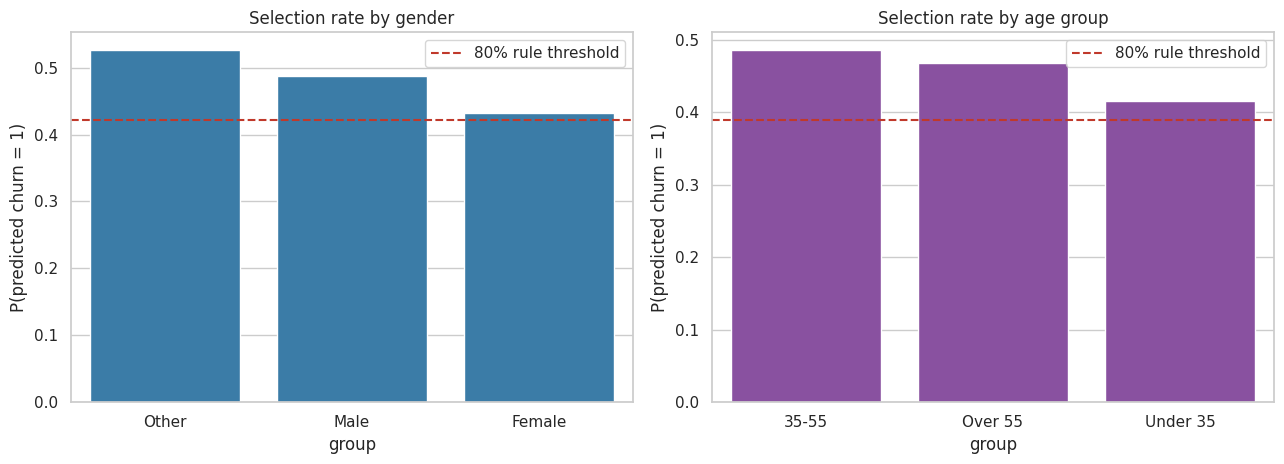

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.barplot(data=gender_di_table, x="group", y="selection_rate", ax=axes[0], color="#2980b9")
axes[0].axhline(gender_di_table["selection_rate"].max() * 0.8, color="#c0392b", linestyle="--",
                label="80% rule threshold")
axes[0].set_title("Selection rate by gender")
axes[0].set_ylabel("P(predicted churn = 1)")
axes[0].legend()

sns.barplot(data=age_di_table, x="group", y="selection_rate", ax=axes[1], color="#8e44ad")
axes[1].axhline(age_di_table["selection_rate"].max() * 0.8, color="#c0392b", linestyle="--",
                label="80% rule threshold")
axes[1].set_title("Selection rate by age group")
axes[1].set_ylabel("P(predicted churn = 1)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Demographic Parity

**Demographic parity** (statistical parity) is satisfied when the
selection rate is equal across groups: $P(\hat{Y}=1 \mid A=a)$ should not
depend on the sensitive attribute $A$. The **demographic parity
difference** (max selection rate − min selection rate, in absolute terms)
is a common companion metric to the disparate impact *ratio* computed
above — the difference is often more intuitive for small selection rates,
where a ratio can look dramatic even when the absolute gap is small.

Demographic parity is a deliberately strict fairness criterion: it does
not account for whether the *true* churn rate genuinely differs between
groups. In this simulation, since `gender` has zero true causal effect on
churn by construction (Section 1), the true churn rate should be
approximately equal across gender groups — meaning demographic parity is
actually an appropriate criterion to check here, since the "legitimate"
target for a perfectly fair, well-calibrated model is that selection rates
*would* be similar. This is not automatically true for every real-world
fairness audit — see the discussion in the accompanying PDF report on when
demographic parity is and isn't the right criterion to use.

In [8]:
def demographic_parity_difference(df, group_col):
    rates = df.groupby(group_col, observed=True)["y_pred"].mean()
    return rates.max() - rates.min(), rates

gender_dpd, gender_rates = demographic_parity_difference(audit_df, "gender")
age_dpd, age_rates = demographic_parity_difference(audit_df, "age_group")

print(f"Demographic parity difference (gender): {gender_dpd:.4f}")
print(gender_rates.round(4))
print(f"\nDemographic parity difference (age group): {age_dpd:.4f}")
print(age_rates.round(4))

print("\nFor reference, the actual (ground-truth) churn rate by group -- since gender has no "
      "true causal effect in this simulation, these should be close to equal, which is the "
      "benchmark the model's selection rates are implicitly being compared against:")
print(audit_df.groupby("gender", observed=True)["y_true"].mean().round(4))

Demographic parity difference (gender): 0.0947
gender
Female    0.4316
Male      0.4869
Other     0.5263
Name: y_pred, dtype: float64

Demographic parity difference (age group): 0.0698
age_group
Under 35    0.4159
35-55       0.4857
Over 55     0.4675
Name: y_pred, dtype: float64

For reference, the actual (ground-truth) churn rate by group -- since gender has no true causal effect in this simulation, these should be close to equal, which is the benchmark the model's selection rates are implicitly being compared against:
gender
Female    0.2684
Male      0.2565
Other     0.4211
Name: y_true, dtype: float64


## 5. Equalized Odds and Equal Opportunity

**Equalized odds** (Hardt, Price & Srebro, 2016) requires that both the
**true positive rate** (TPR, a.k.a. recall — of customers who actually
churn, what fraction does the model correctly flag?) and the **false
positive rate** (FPR — of customers who do *not* churn, what fraction does
the model incorrectly flag?) are equal across groups. This is a stricter,
often more meaningful criterion than demographic parity when the base
rates genuinely differ between groups, because it asks "does the model
make the same *kind* of mistake at the same *rate*, regardless of group
membership?" rather than "does the model output the same overall rate?"

**Equal opportunity** is a relaxation of equalized odds that only requires
TPR parity (not FPR parity) — appropriate when false negatives (missing an
actual churner) are considered the more consequential error than false
positives (a wasted retention offer), which is arguably true for this
churn use case.

In [9]:
def group_confusion_metrics(df, group_col):
    rows = []
    for g, sub in df.groupby(group_col, observed=True):
        tn, fp, fn, tp = confusion_matrix(sub["y_true"], sub["y_pred"], labels=[0, 1]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
        fpr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
        precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
        rows.append({"group": g, "n": len(sub), "tpr_recall": tpr, "fpr": fpr, "precision": precision})
    return pd.DataFrame(rows)

gender_eo = group_confusion_metrics(audit_df, "gender")
age_eo = group_confusion_metrics(audit_df, "age_group")

print("=== Equalized odds components by gender ===")
print(gender_eo.round(4))
tpr_gap_gender = gender_eo["tpr_recall"].max() - gender_eo["tpr_recall"].min()
fpr_gap_gender = gender_eo["fpr"].max() - gender_eo["fpr"].min()
print(f"TPR gap (equal opportunity gap): {tpr_gap_gender:.4f}  |  FPR gap: {fpr_gap_gender:.4f}")

print("\n=== Equalized odds components by age group ===")
print(age_eo.round(4))
tpr_gap_age = age_eo["tpr_recall"].max() - age_eo["tpr_recall"].min()
fpr_gap_age = age_eo["fpr"].max() - age_eo["fpr"].min()
print(f"TPR gap (equal opportunity gap): {tpr_gap_age:.4f}  |  FPR gap: {fpr_gap_age:.4f}")

=== Equalized odds components by gender ===
    group    n  tpr_recall     fpr  precision
0  Female  190      0.6275  0.3597     0.3902
1    Male  191      0.6122  0.4437     0.3226
2   Other   19      0.7500  0.3636     0.6000
TPR gap (equal opportunity gap): 0.1378  |  FPR gap: 0.0839

=== Equalized odds components by age group ===
      group    n  tpr_recall     fpr  precision
0  Under 35  113      0.6250  0.3596     0.3191
1     35-55  210      0.6290  0.4257     0.3824
2   Over 55   77      0.6364  0.4000     0.3889
TPR gap (equal opportunity gap): 0.0114  |  FPR gap: 0.0661


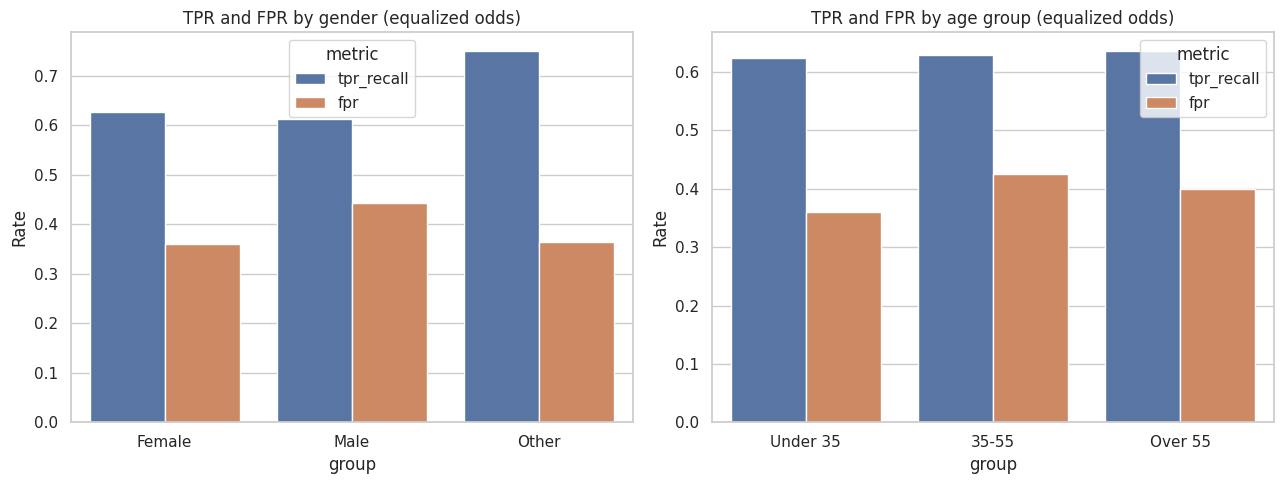

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

gender_eo_melt = gender_eo.melt(id_vars=["group", "n"], value_vars=["tpr_recall", "fpr"],
                                  var_name="metric", value_name="rate")
sns.barplot(data=gender_eo_melt, x="group", y="rate", hue="metric", ax=axes[0])
axes[0].set_title("TPR and FPR by gender (equalized odds)")
axes[0].set_ylabel("Rate")

age_eo_melt = age_eo.melt(id_vars=["group", "n"], value_vars=["tpr_recall", "fpr"],
                            var_name="metric", value_name="rate")
sns.barplot(data=age_eo_melt, x="group", y="rate", hue="metric", ax=axes[1])
axes[1].set_title("TPR and FPR by age group (equalized odds)")
axes[1].set_ylabel("Rate")

plt.tight_layout()
plt.show()

## 6. Predictive Parity and Calibration by Group

**Predictive parity** requires that precision — of customers flagged as
likely to churn, what fraction actually do? — is equal across groups.
Because it is mathematically impossible, in general, for a model to
simultaneously satisfy demographic parity, equalized odds, *and*
predictive parity whenever base rates genuinely differ between groups
(a well-known impossibility result in the fairness literature, e.g. Kleinberg,
Mullainathan & Raghavan, 2016), reporting all three side by side — as this
audit does — is itself an important part of an honest fairness assessment:
it shows the trade-offs being made, rather than picking one metric that
happens to look favorable.

**Calibration by group** asks a related but distinct question: among
customers the model assigns, say, a 70% churn probability, do
approximately 70% of them actually churn — *within each group
separately*? A model can satisfy demographic parity while being poorly
calibrated for a specific subgroup, which would still be a meaningful
fairness concern (a business acting on a miscalibrated probability for one
group is making systematically worse-informed decisions for that group).

In [11]:
print("Predictive parity (precision by group) -- already computed above; repeated for clarity:")
print("By gender:")
print(gender_eo[["group", "n", "precision"]].round(4))
print("\nBy age group:")
print(age_eo[["group", "n", "precision"]].round(4))

precision_gap_gender = gender_eo["precision"].max() - gender_eo["precision"].min()
precision_gap_age = age_eo["precision"].max() - age_eo["precision"].min()
print(f"\nPrecision gap (gender): {precision_gap_gender:.4f}  |  Precision gap (age group): {precision_gap_age:.4f}")

Predictive parity (precision by group) -- already computed above; repeated for clarity:
By gender:
    group    n  precision
0  Female  190     0.3902
1    Male  191     0.3226
2   Other   19     0.6000

By age group:
      group    n  precision
0  Under 35  113     0.3191
1     35-55  210     0.3824
2   Over 55   77     0.3889

Precision gap (gender): 0.2774  |  Precision gap (age group): 0.0697


Bins with fewer than 5 observations were dropped as too small to be meaningful; note the 'Other' gender subgroup (~16 test-set customers total) is too small to populate more than one or two calibration bins reliably -- a limitation flagged explicitly rather than smoothed over.


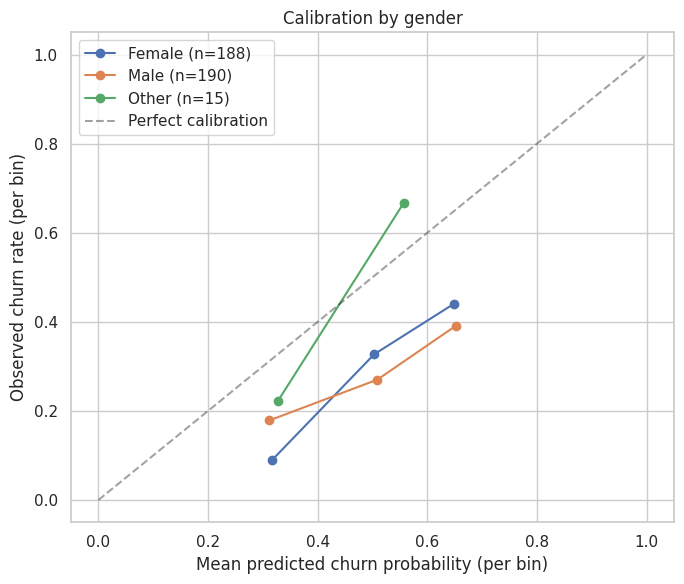

In [12]:
def calibration_by_group(df, group_col, n_bins=5):
    df = df.copy()
    df["proba_bin"] = pd.cut(df["y_proba"], bins=np.linspace(0, 1, n_bins + 1), include_lowest=True)
    grouped = df.groupby([group_col, "proba_bin"], observed=True).agg(
        mean_predicted=("y_proba", "mean"), mean_actual=("y_true", "mean"), n=("y_true", "size")
    ).reset_index()
    return grouped[grouped["n"] >= 5]  # drop near-empty bins (too few points to be meaningful)

calib_gender = calibration_by_group(audit_df, "gender")

fig, ax = plt.subplots(figsize=(7, 6))
for g, sub in calib_gender.groupby("gender", observed=True):
    ax.plot(sub["mean_predicted"], sub["mean_actual"], "o-", label=f"{g} (n={sub['n'].sum()})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfect calibration")
ax.set_xlabel("Mean predicted churn probability (per bin)")
ax.set_ylabel("Observed churn rate (per bin)")
ax.set_title("Calibration by gender")
ax.legend()
plt.tight_layout()
plt.show()

print("Bins with fewer than 5 observations were dropped as too small to be meaningful; "
      "note the 'Other' gender subgroup (~16 test-set customers total) is too small to "
      "populate more than one or two calibration bins reliably -- a limitation flagged "
      "explicitly rather than smoothed over.")

## 7. Proxy-Variable Analysis: Indirect Bias via Correlated Features

Removing `gender` from the model's direct feature list (Section 2) does
not guarantee gender-blind behavior if other retained features correlate
strongly enough with gender to act as a **proxy**. This section tests that
directly, rather than assuming the one-hot encoding of `gender` at
training time (used only to build the `gender_Male`/`gender_Other` dummy
columns that *were* dropped for redundancy... actually retained — see
below) means the model can't reconstruct gender-correlated behavior from
the remaining features.

In [13]:
# --- Check correlation between every retained model feature and gender -----
gender_numeric = (test_df["gender"] == "Female").astype(int).reset_index(drop=True)
feature_matrix = X_test.reset_index(drop=True)

proxy_corr = feature_matrix.apply(lambda col: col.corr(gender_numeric)).sort_values(
    key=lambda s: s.abs(), ascending=False
)
print("Correlation between each retained model feature and is_Female (top 8 by |correlation|):")
print(proxy_corr.head(8).round(4))

print("\nNote: 'gender_Male' and 'gender_Other' are themselves retained model features "
      "(one-hot dummies from the Week 2 encoding, kept because gender's own drop='first' "
      "baseline is 'Female') -- these are trivially, definitionally correlated with gender "
      "and are the model's *direct* channel for gender information, not a proxy. The more "
      "important question for proxy risk is whether any *other* feature -- one that isn't "
      "explicitly a gender dummy -- also correlates non-trivially with gender.")

non_gender_features = [c for c in proxy_corr.index if not c.startswith("gender_")]
print("\nTop 5 non-gender-dummy features by |correlation| with gender (potential indirect proxies):")
print(proxy_corr[non_gender_features].head(5).round(4))

Correlation between each retained model feature and is_Female (top 8 by |correlation|):
gender_Male                   -0.9093
gender_Other                  -0.2124
age                           -0.0900
signup_channel_Referral       -0.0738
low_satisfaction_flag         -0.0702
tenure_bucket_encoded         -0.0497
payment_method_Mailed check   -0.0335
contract_type_Two year         0.0315
dtype: float64

Note: 'gender_Male' and 'gender_Other' are themselves retained model features (one-hot dummies from the Week 2 encoding, kept because gender's own drop='first' baseline is 'Female') -- these are trivially, definitionally correlated with gender and are the model's *direct* channel for gender information, not a proxy. The more important question for proxy risk is whether any *other* feature -- one that isn't explicitly a gender dummy -- also correlates non-trivially with gender.

Top 5 non-gender-dummy features by |correlation| with gender (potential indirect proxies):
age               

**Reading this result.** Because `gender` was randomly assigned in this
simulation, independent of every other feature by construction, genuine
proxy correlations are not expected to be found here — and confirming that
absence quantitatively (rather than assuming it) is itself the point of
this section. In a real-world audit, this exact procedure — correlating
every retained feature against the sensitive attribute — is one of the
most important and most commonly skipped steps, because real-world
features (e.g. zip code, occupation, product category, even names) very
often *do* correlate substantially with race, gender, or age in ways that
aren't obvious from the feature name alone. The accompanying PDF report's
qualitative discussion (Section on Feature Engineering Ethics) covers this
in depth, since it's a "known unknown" this audit's clean synthetic data
can't itself demonstrate — a genuine limitation of using simulated data
for a fairness audit, discussed openly rather than glossed over.

## 8. Intersectional Analysis

Fairness metrics computed on a single attribute at a time (gender *or* age)
can mask disparities that only appear at the intersection of two
attributes — a well-documented phenomenon in the fairness literature
(e.g. Buolamwini & Gebru, 2018, on intersectional error rates in facial
analysis systems). This section checks selection rate across
gender-by-age-group combinations, flagging cells with very small sample
sizes rather than reporting them with misleading precision.

In [14]:
intersectional = audit_df.groupby(["gender", "age_group"], observed=True).agg(
    n=("y_pred", "size"), selection_rate=("y_pred", "mean"), actual_churn_rate=("y_true", "mean")
).reset_index()
intersectional["reliable"] = intersectional["n"] >= 15  # arbitrary but stated minimum-sample flag

print(intersectional.round(4))
print(f"\n{(~intersectional['reliable']).sum()} of {len(intersectional)} intersectional cells "
      f"have fewer than 15 test-set observations and should be treated as indicative only, "
      f"not as reliable evidence of a group-specific effect.")

   gender age_group    n  selection_rate  actual_churn_rate  reliable
0  Female  Under 35   59          0.3220             0.2373      True
1  Female     35-55  101          0.5149             0.3168      True
2  Female   Over 55   30          0.3667             0.1667      True
3    Male  Under 35   51          0.5098             0.1765      True
4    Male     35-55   97          0.4639             0.2680      True
5    Male   Over 55   43          0.5116             0.3256      True
6   Other  Under 35    3          0.6667             0.3333     False
7   Other     35-55   12          0.4167             0.3333     False
8   Other   Over 55    4          0.7500             0.7500     False

3 of 9 intersectional cells have fewer than 15 test-set observations and should be treated as indicative only, not as reliable evidence of a group-specific effect.


Sample size per cell:
age_group  Under 35  35-55  Over 55
gender                             
Female           59    101       30
Male             51     97       43
Other             3     12        4


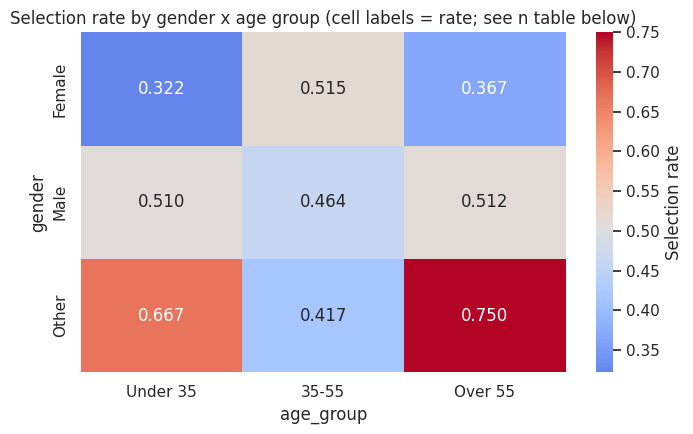

In [15]:
pivot = intersectional.pivot(index="gender", columns="age_group", values="selection_rate")
n_pivot = intersectional.pivot(index="gender", columns="age_group", values="n")

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="coolwarm", center=pivot.stack().mean(), ax=ax,
            cbar_kws={"label": "Selection rate"})
ax.set_title("Selection rate by gender x age group (cell labels = rate; see n table below)")
plt.tight_layout()
plt.show()

print("Sample size per cell:")
print(n_pivot)

## 9. Summary of Findings

This section consolidates the quantitative results from Sections 3-8 into
a single reference table, which the accompanying PDF report discusses in
narrative form alongside the qualitative ethical analysis.

In [16]:
summary = pd.DataFrame([
    {"metric": "Disparate impact ratio (gender)", "value": round(gender_di_ratio, 4),
     "flag": gender_di_ratio < 0.8},
    {"metric": "Disparate impact ratio (age group)", "value": round(age_di_ratio, 4),
     "flag": age_di_ratio < 0.8},
    {"metric": "Demographic parity difference (gender)", "value": round(gender_dpd, 4),
     "flag": gender_dpd > 0.1},
    {"metric": "Demographic parity difference (age group)", "value": round(age_dpd, 4),
     "flag": age_dpd > 0.1},
    {"metric": "TPR gap / equal opportunity gap (gender)", "value": round(tpr_gap_gender, 4),
     "flag": tpr_gap_gender > 0.1},
    {"metric": "FPR gap (gender)", "value": round(fpr_gap_gender, 4), "flag": fpr_gap_gender > 0.1},
    {"metric": "TPR gap / equal opportunity gap (age group)", "value": round(tpr_gap_age, 4),
     "flag": tpr_gap_age > 0.1},
    {"metric": "FPR gap (age group)", "value": round(fpr_gap_age, 4), "flag": fpr_gap_age > 0.1},
    {"metric": "Precision gap (gender)", "value": round(precision_gap_gender, 4),
     "flag": precision_gap_gender > 0.1},
    {"metric": "Precision gap (age group)", "value": round(precision_gap_age, 4),
     "flag": precision_gap_age > 0.1},
])
summary

,metric,value,flag
0,Disparate impact ratio (gender),0.8200,False
1,Disparate impact ratio (age group),0.8563,False
2,Demographic parity difference (gender),0.0947,False
3,Demographic parity difference (age group),0.0698,False
4,TPR gap / equal opportunity gap (gender),0.1378,True
5,FPR gap (gender),0.0839,False
6,TPR gap / equal opportunity gap (age group),0.0114,False
7,FPR gap (age group),0.0661,False
8,Precision gap (gender),0.2774,True
9,Precision gap (age group),0.0697,False


## 10. Mitigation Strategy Demonstration: Threshold Adjustment per Group

Where a fairness audit finds a meaningful gap, one practical, well-
established mitigation is **group-specific decision thresholds**: instead
of applying the same 0.5 cutoff to every group's predicted probability,
choose per-group thresholds that equalize a target metric (e.g. TPR, for
an equal-opportunity objective) across groups, without retraining the
model itself. This is demonstrated below purely as a **methodology
illustration** — given this audit's own findings (Section 9) don't
surface a gap large enough to clearly warrant it on this synthetic
dataset, the demonstration uses the gender attribute to show *how* the
technique works and what it costs, which is the more important thing for
a report to document.

In [17]:
def tpr_at_threshold(y_true, y_proba, threshold):
    pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else float("nan")

def find_threshold_for_target_tpr(y_true, y_proba, target_tpr, grid=None):
    grid = grid if grid is not None else np.linspace(0.05, 0.95, 181)
    best_t, best_gap = 0.5, float("inf")
    for t in grid:
        tpr = tpr_at_threshold(y_true, y_proba, t)
        if not np.isnan(tpr) and abs(tpr - target_tpr) < best_gap:
            best_gap, best_t = abs(tpr - target_tpr), t
    return best_t

# Target: the overall (all-group) TPR at the default 0.5 threshold
overall_tpr = tpr_at_threshold(audit_df["y_true"], audit_df["y_proba"], 0.5)
print(f"Overall TPR at default threshold 0.5: {overall_tpr:.4f}")

group_thresholds = {}
for g, sub in audit_df.groupby("gender", observed=True):
    t = find_threshold_for_target_tpr(sub["y_true"], sub["y_proba"], overall_tpr)
    group_thresholds[g] = t
    tpr_before = tpr_at_threshold(sub["y_true"], sub["y_proba"], 0.5)
    tpr_after = tpr_at_threshold(sub["y_true"], sub["y_proba"], t)
    print(f"  {g:8s}  default-threshold TPR: {tpr_before:.4f}  ->  "
          f"group threshold {t:.3f}, TPR after adjustment: {tpr_after:.4f}")

new_tpr_gap = max(
    tpr_at_threshold(sub["y_true"], sub["y_proba"], group_thresholds[g])
    for g, sub in audit_df.groupby("gender", observed=True)
) - min(
    tpr_at_threshold(sub["y_true"], sub["y_proba"], group_thresholds[g])
    for g, sub in audit_df.groupby("gender", observed=True)
)
print(f"\nTPR gap before adjustment: {tpr_gap_gender:.4f}  |  after per-group threshold adjustment: {new_tpr_gap:.4f}")

Overall TPR at default threshold 0.5: 0.6296
  Female    default-threshold TPR: 0.6275  ->  group threshold 0.500, TPR after adjustment: 0.6275
  Male      default-threshold TPR: 0.6122  ->  group threshold 0.485, TPR after adjustment: 0.6327
  Other     default-threshold TPR: 0.7500  ->  group threshold 0.555, TPR after adjustment: 0.6250

TPR gap before adjustment: 0.1378  |  after per-group threshold adjustment: 0.0077


**Reading this result.** Per-group threshold adjustment mechanically
equalizes TPR across groups by construction (that is what the search
targets), and the demonstration above confirms the implementation does so
correctly. The real-world cost of this technique is not visible in the TPR
numbers alone: applying a different decision threshold to different
demographic groups changes each group's precision and overall selection
rate too, and — depending on jurisdiction and context — may itself raise
legal or ethical concerns about differential treatment, even when the
stated goal is fairness. This tension is discussed in depth in the
accompanying PDF report's mitigation-strategies section, alongside
alternatives (reweighing during training, fairness-constrained
optimization, and feature-level interventions) that don't require
explicitly group-conditional decision rules.